In [1]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
housing = housing['data'].join(housing['target']).sample(1000, random_state=52)
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
7506,3.0550,37.0,5.152778,1.048611,729.0,5.062500,33.92,-118.28,1.054
4720,3.0862,35.0,4.697897,1.055449,1159.0,2.216061,34.05,-118.37,3.453
12888,2.5556,24.0,4.864905,1.129222,1631.0,2.395007,38.66,-121.35,1.057
13344,3.0057,32.0,4.212687,0.936567,1378.0,5.141791,34.05,-117.64,0.969
7173,1.9083,42.0,3.888554,1.039157,1535.0,4.623494,34.05,-118.19,1.192


We can see all the correlation coefficients for every combination of columns in this dataset by calling `np.corrcoef`

In [2]:
import numpy as np

np.set_printoptions(precision=2, suppress=True)
np.corrcoef(housing, rowvar=False)

array([[ 1.  , -0.12,  0.43, -0.08,  0.01, -0.07, -0.12,  0.04,  0.68],
       [-0.12,  1.  , -0.17, -0.06, -0.31,  0.  ,  0.03, -0.13,  0.12],
       [ 0.43, -0.17,  1.  ,  0.76, -0.09, -0.07,  0.12, -0.03,  0.21],
       [-0.08, -0.06,  0.76,  1.  , -0.08, -0.07,  0.09,  0.  , -0.04],
       [ 0.01, -0.31, -0.09, -0.08,  1.  ,  0.16, -0.15,  0.13,  0.  ],
       [-0.07,  0.  , -0.07, -0.07,  0.16,  1.  , -0.16,  0.17, -0.27],
       [-0.12,  0.03,  0.12,  0.09, -0.15, -0.16,  1.  , -0.93, -0.16],
       [ 0.04, -0.13, -0.03,  0.  ,  0.13,  0.17, -0.93,  1.  , -0.03],
       [ 0.68,  0.12,  0.21, -0.04,  0.  , -0.27, -0.16, -0.03,  1.  ]])

Same this as hit map

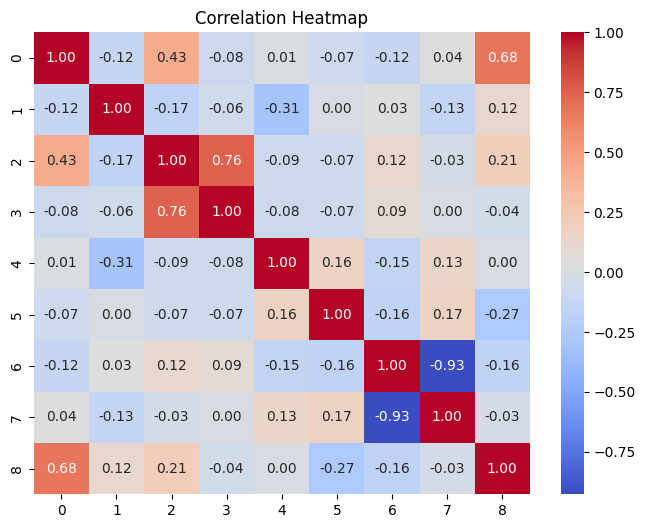

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# correlation matrix
corr = np.corrcoef(housing, rowvar=False)

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

This works well when we're getting a bunch of values at once, but it's overkill when we want a single coefficient:

In [4]:
np.corrcoef(housing.MedInc, housing.MedHouseVal)

array([[1.  , 0.68],
       [0.68, 1.  ]])

Therefore, we'll create this little function to just return the single number we need given a pair of variables:

In [9]:
def corr(x, y):
    return np.corrcoef(x, y)[0][1]

In [10]:
corr(housing.MedInc, housing.MedHouseVal)

np.float64(0.6760250732906005)

Now we'll look at a few examples of correlations, using this function (the details of the function don't matter too much):

In [13]:
def show_corr(df, a, b):
    x, y = df[a], df[b]
    plt.scatter(x, y, alpha=0.5, s=4)
    plt.xlabel(a)
    plt.ylabel(b)
    plt.title(f"{a} vs {b}: r: {corr(x,y):.2f}")

OK, let's check out the correlation between income and house value:

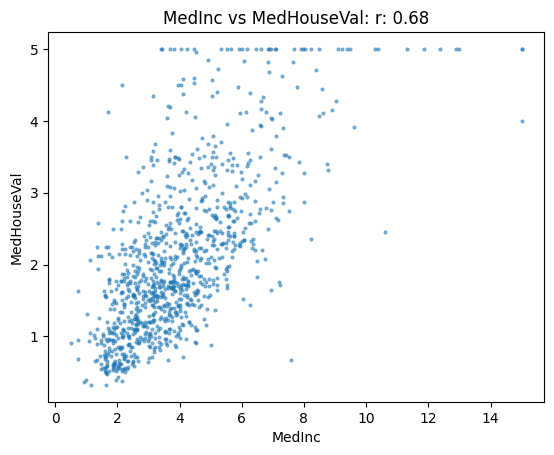

In [14]:
show_corr(housing, 'MedInc', 'MedHouseVal')

So that's what a correlation of 0.68 looks like. It's quite a close relationship, but there's still a lot of variation. (Incidentally, this also shows why looking at your data is so important -- we can see clearly in this plot that house prices above $500,000 seem to have been truncated to that maximum value).

Let's take a look at another pair:

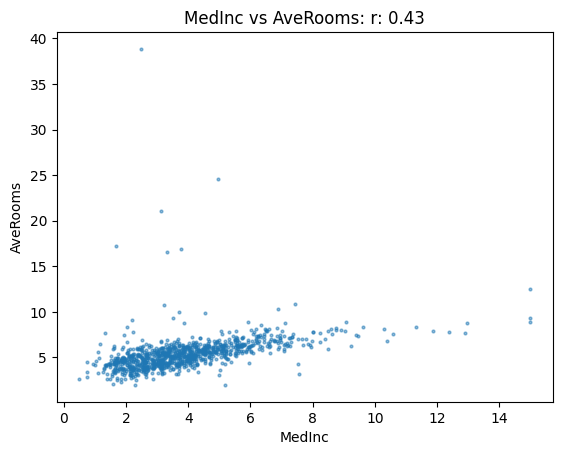

In [15]:
show_corr(housing, 'MedInc', 'AveRooms')

The relationship looks like it is similarly close to the previous example, but r is much lower than the income vs valuation case. Why is that? The reason is that there are a lot of outliers -- values of AveRooms well outside the mean.

r is very sensitive to outliers. If there's outliers in your data, then the relationship between them will dominate the metric. In this case, the houses with a very high number of rooms don't tend to be that valuable, so it's decreasing r from where it would otherwise be.

Let's remove the outliers and try again:

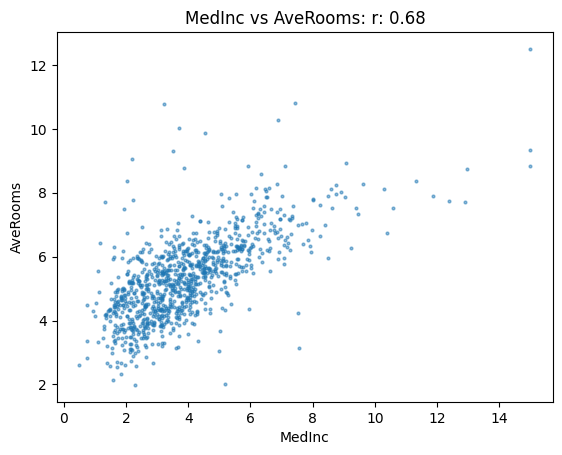

In [20]:
subset = housing[housing.AveRooms<15]
show_corr(subset, 'MedInc', 'AveRooms')

As we expected, now the correlation is very similar to our first comparison.

Here's another relationship using AveRooms on the subset:

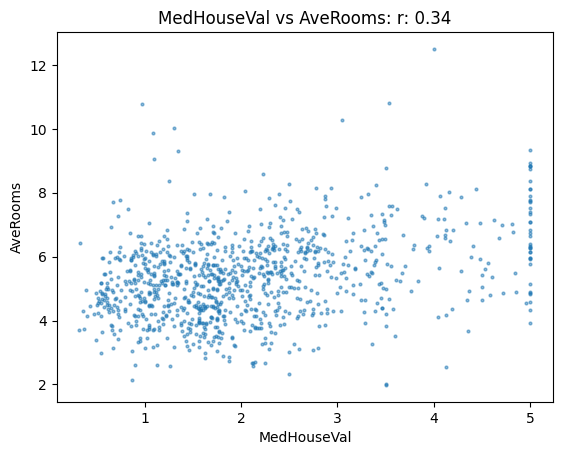

In [21]:
show_corr(subset, 'MedHouseVal', 'AveRooms')

At this level, with r of 0.34, the relationship is becoming quite weak.

Let's look at one more:

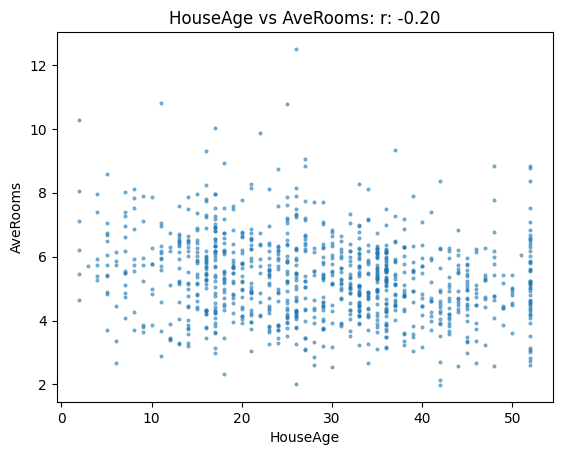

In [22]:
show_corr(subset, 'HouseAge', 'AveRooms')

As you see here, a correlation of -0.2 shows a very weak negative trend.

We've seen now examples of a variety of levels of correlation coefficient, so hopefully you're getting a good sense of what this metric means.
